<a href="https://colab.research.google.com/github/engineerchacon/Redes-Neuronales-Profundas/blob/main/Transformers_(an%C3%A1lisis_de_sentimiento)_Armando_Chac%C3%B3n_Terrazas_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1: Configuración y Carga de Datos**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Configuración de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detectada: {tf.test.gpu_device_name()}")
    except RuntimeError as e:
        print(e)

# 2. Parámetros Globales
VOCAB_SIZE = 20000
MAX_LEN = 200
EMB_DIM = 128
BATCH = 64
VAL_SPLIT = 0.15

# 3. Carga y Preprocesamiento
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding="pre", truncating="pre")

# Split de validación
n_val = int(len(x_train) * VAL_SPLIT)
x_val, y_val = x_train[:n_val], y_train[:n_val]
x_trn, y_trn = x_train[n_val:], y_train[n_val:]
print(f"✅ Datos listos. Entrenamiento: {len(x_trn)}, Validación: {len(x_val)}")

✅ GPU detectada: /device:GPU:0
✅ Datos listos. Entrenamiento: 21250, Validación: 3750


# **2: Arquitectura del Bloque Transformer**

In [2]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token = layers.Embedding(vocab_size, embed_dim)
        self.pos = layers.Embedding(max_len, embed_dim)
        self.max_len = max_len
    def call(self, x):
        positions = tf.range(0, self.max_len)
        return self.token(x) + self.pos(positions)

def transformer_block(x, use_multihead=True):
    # 1. Mecanismo de Atención (MHA o Simple)
    if use_multihead:
        attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=EMB_DIM // 4)(x, x)
    else:
        attn_out = layers.Attention()([x, x])

    # 2. Primer Residual + LayerNorm (Atención)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # 3. Feed-Forward Network (MLP)
    ff = layers.Dense(EMB_DIM * 2, activation="relu")(x)
    ff = layers.Dense(EMB_DIM)(ff)

    # 4. Segundo Residual + LayerNorm (FFN)
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x

# **3: Construcción y Entrenamiento de Modelos**

In [3]:
def build_transformer_selfatt():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=False)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name="Transformer_SelfAtt")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_transformer_mha():
    inp = layers.Input(shape=(MAX_LEN,), dtype="int32")
    x = PositionalEmbedding(VOCAB_SIZE, EMB_DIM, MAX_LEN)(inp)
    x = transformer_block(x, use_multihead=True)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inp, out, name="Transformer_MultiHead")
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Entrenamiento
selfatt_tx = build_transformer_selfatt()
mha_tx = build_transformer_mha()

print("\n=== Entrenando Transformer (Self-Attention) ===")
hist_self = selfatt_tx.fit(x_trn, y_trn, validation_data=(x_val, y_val), epochs=20, batch_size=BATCH, verbose=2)

print("\n=== Entrenando Transformer (MultiHeadAttention) ===")
hist_mha = mha_tx.fit(x_trn, y_trn, validation_data=(x_val, y_val), epochs=20, batch_size=BATCH, verbose=2)


=== Entrenando Transformer (Self-Attention) ===
Epoch 1/20
333/333 - 11s - 34ms/step - accuracy: 0.7761 - loss: 0.4638 - val_accuracy: 0.8408 - val_loss: 0.3475
Epoch 2/20
333/333 - 2s - 7ms/step - accuracy: 0.9016 - loss: 0.2503 - val_accuracy: 0.8208 - val_loss: 0.4189
Epoch 3/20
333/333 - 2s - 8ms/step - accuracy: 0.9384 - loss: 0.1729 - val_accuracy: 0.8219 - val_loss: 0.4428
Epoch 4/20
333/333 - 3s - 8ms/step - accuracy: 0.9547 - loss: 0.1228 - val_accuracy: 0.8413 - val_loss: 0.4492
Epoch 5/20
333/333 - 5s - 15ms/step - accuracy: 0.9693 - loss: 0.0912 - val_accuracy: 0.8744 - val_loss: 0.3649
Epoch 6/20
333/333 - 3s - 8ms/step - accuracy: 0.9791 - loss: 0.0628 - val_accuracy: 0.8629 - val_loss: 0.4529
Epoch 7/20
333/333 - 3s - 8ms/step - accuracy: 0.9860 - loss: 0.0474 - val_accuracy: 0.8669 - val_loss: 0.4681
Epoch 8/20
333/333 - 3s - 8ms/step - accuracy: 0.9902 - loss: 0.0324 - val_accuracy: 0.8672 - val_loss: 0.5013
Epoch 9/20
333/333 - 3s - 8ms/step - accuracy: 0.9923 - loss

# **4: Resultados, Curvas y Tabla Comparativa**


=== TABLA COMPARATIVA ===
                    Modelo  Test Accuracy  Test Loss
Transformer Self-Attention        0.84464   1.382420
    Transformer Multi-Head        0.82452   1.182286


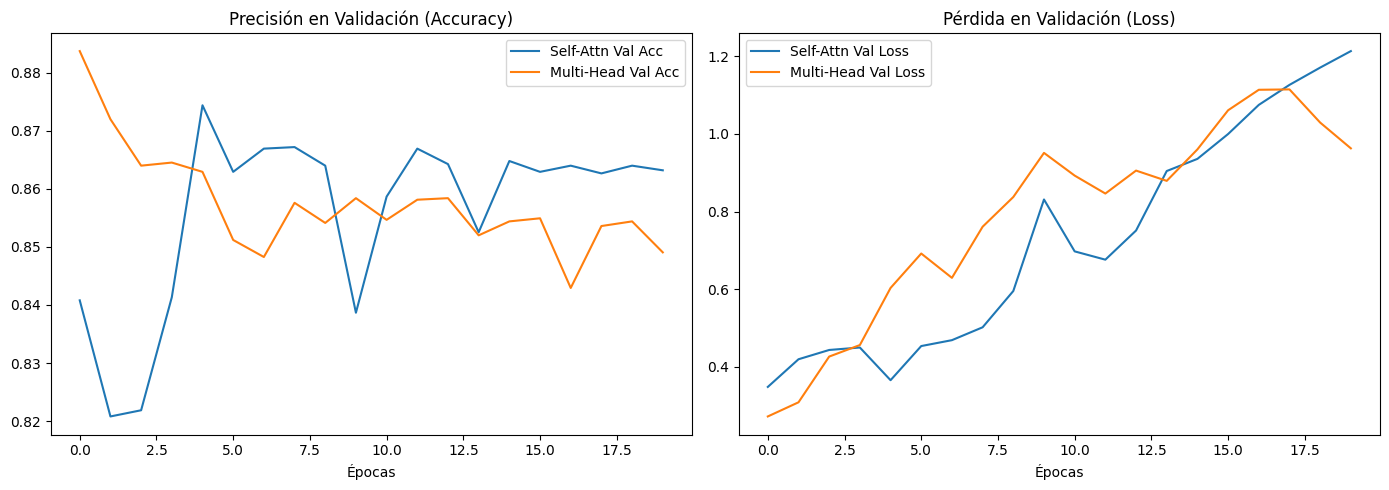

In [4]:
# 1. Evaluación Final
test_self = selfatt_tx.evaluate(x_test, y_test, verbose=0)
test_mha = mha_tx.evaluate(x_test, y_test, verbose=0)

# 2. Tabla Comparativa
resultados = {
    "Modelo": ["Transformer Self-Attention", "Transformer Multi-Head"],
    "Test Accuracy": [test_self[1], test_mha[1]],
    "Test Loss": [test_self[0], test_mha[0]]
}
df_comparativo = pd.DataFrame(resultados)
print("\n=== TABLA COMPARATIVA ===")
print(df_comparativo.to_string(index=False))

# 3. Gráficas de Accuracy y Loss
plt.figure(figsize=(14, 5))

# Curvas de Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_self.history['val_accuracy'], label='Self-Attn Val Acc')
plt.plot(hist_mha.history['val_accuracy'], label='Multi-Head Val Acc')
plt.title('Precisión en Validación (Accuracy)')
plt.xlabel('Épocas')
plt.legend()

# Curvas de Loss
plt.subplot(1, 2, 2)
plt.plot(hist_self.history['val_loss'], label='Self-Attn Val Loss')
plt.plot(hist_mha.history['val_loss'], label='Multi-Head Val Loss')
plt.title('Pérdida en Validación (Loss)')
plt.xlabel('Épocas')
plt.legend()

plt.tight_layout()
plt.show()